__Dataset de Depósitos Bancarios a Plazo (Clasificación)__

1: Importación de librerías

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision, Recall

2: Carga de datos con tu ruta local fija

In [2]:
# Definimos la ruta exacta según tu terminal de PowerShell
DATA_PATH = r"C:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\data\data_original\bank_term_deposit\bank_term_deposit.csv"

# Cargar el dataset
df = pd.read_csv(DATA_PATH)

# Filtrar: Nos quedamos SOLO con las filas etiquetadas y eliminamos el leaderboard
df_labeled = df[df['split'] == 'labeled'].copy()

# Eliminar columnas de control que no aportan al aprendizaje de la red
df_labeled = df_labeled.drop(columns=['id', 'split'])

print(f"Forma del dataset original: {df.shape}")
print(f"Forma tras remover el leaderboard: {df_labeled.shape}")

Forma del dataset original: (3063, 19)
Forma tras remover el leaderboard: (2007, 17)


3: Separación de Features/Target y Selección Óptima mediante Random Forest

In [3]:
# Separar X e y (El target es 'y' que indica si contrata el depósito: "yes"/"no")
X_full = df_labeled.drop(columns=['y'])
y_full = df_labeled['y'].map({'yes': 1, 'no': 0}) # Codificación binaria rápida

# Preprocesamiento exprés para el Random Forest (solo numéricas y dummies rápidas)
X_encoded = pd.get_dummies(X_full, drop_first=True)

# Entrenar un RandomForest rápido para medir importancia
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_encoded, y_full)

# Obtener las 5 mejores features mapeando los nombres originales
importances = pd.Series(rf.feature_importances_, index=X_encoded.columns).sort_values(ascending=False)
print("--- Top 5 Features más importantes encontradas ---")
print(importances.head(5))

# Seleccionamos las columnas del DataFrame original relacionadas con el Top (ej: 'duration', 'balance', 'age', 'day')
# Ajusta esta lista si el Random Forest te devuelve variables dummies específicas de columnas categóricas
FEATURES_OPTIMAS = ['duration', 'balance', 'age', 'day', 'campaign'] 

X = X_full[FEATURES_OPTIMAS]
y = y_full.values

# División en Entrenamiento y Validación (80% / 20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

--- Top 5 Features más importantes encontradas ---
duration            0.383384
poutcome_success    0.113092
age                 0.067819
balance             0.060713
day                 0.045592
dtype: float64


4: Pipeline de Preprocesamiento para la Red Neuronal

In [4]:
# Identificar numéricas y categóricas del subconjunto óptimo
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Crear transformadores
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) # Crucial para Redes Neuronales
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Aplicar transformaciones
X_train_p = preprocessor.fit_transform(X_train)
X_val_p = preprocessor.transform(X_val)

input_dim = X_train_p.shape[1]
print(f"Dimensiones de entrada listas para la NN: {input_dim}")

Dimensiones de entrada listas para la NN: 5


5: Construcción de la NN y Configuración de Early Stopping

In [5]:
# 1. Definir la arquitectura para clasificación binaria
model = Sequential([
    Input(shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid para salida binaria (probabilidad 0 a 1)
])

# 2. Compilar el modelo incorporando Métricas de Clasificación (Precision y Recall)
model.compile(
    optimizer=Adam(learning_rate=0.005),
    loss='binary_crossentropy', # Pérdida estándar para clasificación binaria
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

# 3. Definir el Callback de Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=15,          # Detiene si el val_loss no mejora en 15 épocas consecutivas
    restore_best_weights=True # Recupera los pesos de la mejor época
)

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

None


6: Entrenamiento del Modelo

In [6]:
print("Iniciando el entrenamiento con Early Stopping en el subset óptimo...")

history = model.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=200,              # Ponemos un máximo alto, Early Stopping actuará antes
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Iniciando el entrenamiento con Early Stopping en el subset óptimo...
Epoch 1/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9252 - loss: 0.2913 - precision: 0.7436 - recall: 0.2086 - val_accuracy: 0.9378 - val_loss: 0.1872 - val_precision: 0.6923 - val_recall: 0.5143
Epoch 2/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9352 - loss: 0.1827 - precision: 0.7215 - recall: 0.4101 - val_accuracy: 0.9378 - val_loss: 0.1782 - val_precision: 0.6667 - val_recall: 0.5714
Epoch 3/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9364 - loss: 0.1742 - precision: 0.6947 - recall: 0.4748 - val_accuracy: 0.9378 - val_loss: 0.1692 - val_precision: 0.6667 - val_recall: 0.5714
Epoch 4/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9377 - loss: 0.1688 - precision: 0.7294 - recall: 0.4460 - val_accuracy: 0.9428 - val_loss: 0.1652 - val_precision: 0.7143 - val_recall: 0.5714
Epoch 5/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9414 - loss: 0.1640 - precisio

7: Visualización de las curvas en Celda Aparte

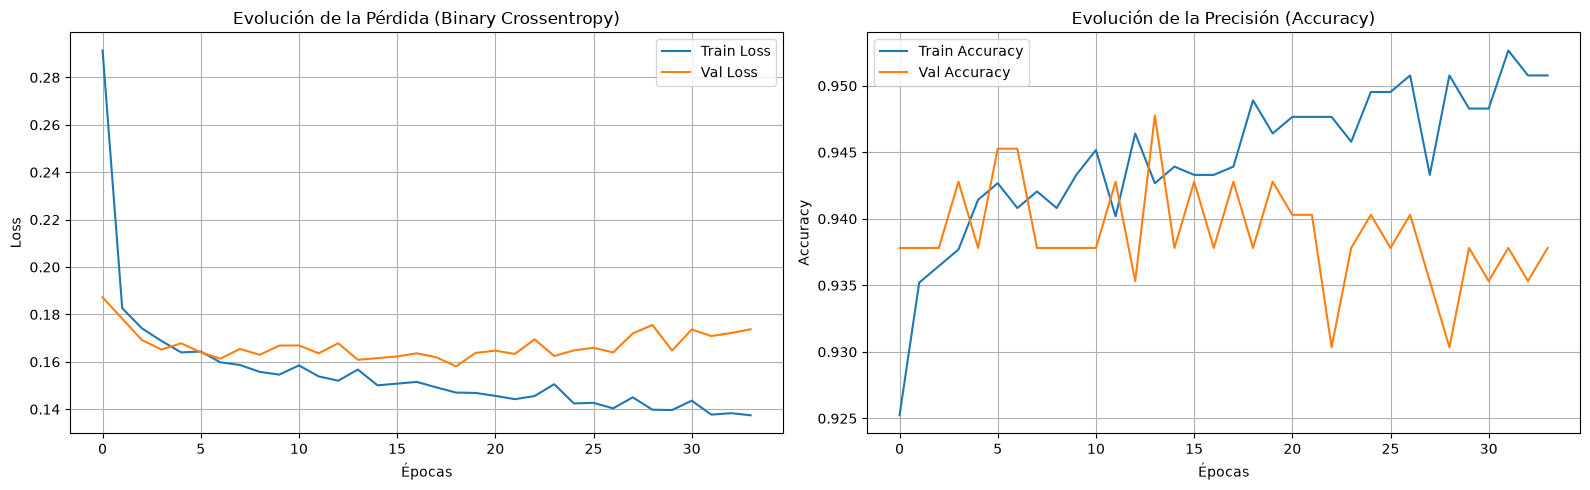

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de Pérdida (Loss)
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Evolución de la Pérdida (Binary Crossentropy)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Gráfico de Accuracy / Precisión
ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Evolución de la Precisión (Accuracy)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()